In [1]:
# jakob2019_figuras.ipynb
# Bloque 1 — Setup
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ssl, certifi, os
from pathlib import Path

# SSL fix para cartopy
ssl._create_default_https_context = ssl.create_default_context
os.environ['SSL_CERT_FILE'] = certifi.where()

# Rutas
ROOT    = Path.cwd()
OUT_DIR = ROOT / 'datos' / 'procesados'
FIG_DIR = ROOT / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cargar los 4 campos procesados
Q_R   = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E   = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H     = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')
D_RCE = xr.open_dataarray(OUT_DIR / 'D_RCE_2001_2009.nc')

print("Datos cargados:")
for name, da in [("Q_R", Q_R), ("P_E", P_E), ("H", H), ("D_RCE", D_RCE)]:
    print(f"  {name}: {da.shape}  {da.time.values[0]} → {da.time.values[-1]}")

Datos cargados:
  Q_R: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  P_E: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  H: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  D_RCE: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


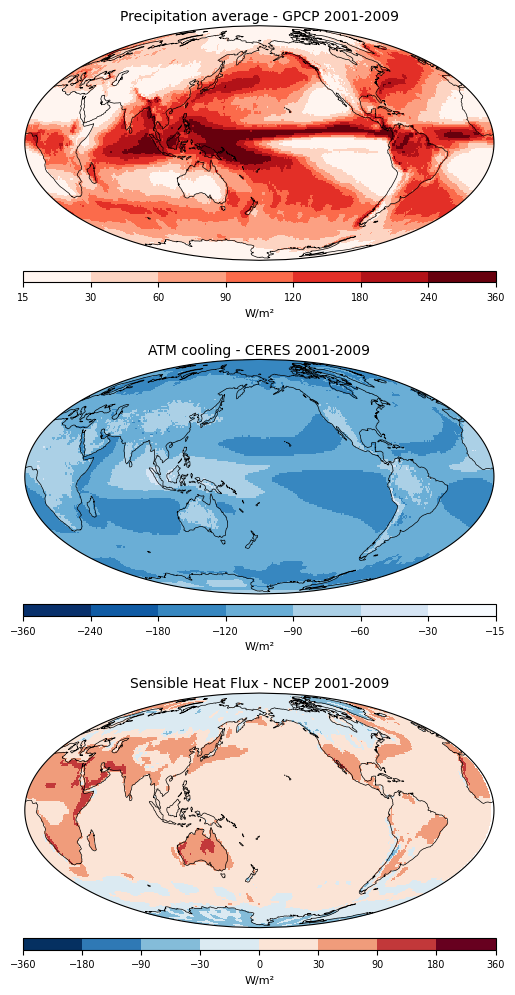

Guardada: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/figuras/fig01_jakob2019.png


In [12]:
# SSL fix para cartopy
ssl._create_default_https_context = ssl.create_default_context
os.environ['SSL_CERT_FILE'] = certifi.where()

# Rutas
OUT_DIR = ROOT / 'datos' / 'procesados'
FIG_DIR = ROOT / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cargar datos procesados
Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')

# Promedios 9 años
Q_R_mean = Q_R.mean('time').compute()
P_E_mean = P_E.mean('time').compute()
H_mean   = H.mean('time').compute()

Q_R_plot = Q_R_mean
P_E_plot = P_E_mean
H_plot   = H_mean

# Plot — central_longitude=180 como en el paper
proj = ccrs.Mollweide(central_longitude=180)
fig, axes = plt.subplots(3, 1, figsize=(10, 12),
                         subplot_kw={'projection': proj})
fig.subplots_adjust(hspace=0.3)

from matplotlib.colors import BoundaryNorm

configs = [
    (P_E_plot, "Precipitation average - GPCP 2001-2009",
     plt.cm.Reds,
     [15, 30, 60, 90, 120, 180, 240, 360], "W/m²"),
    (Q_R_plot, "ATM cooling - CERES 2001-2009",
     plt.cm.Blues_r,
     [-360, -240, -180, -120, -90, -60, -30, -15], "W/m²"),
    (H_plot,   "Sensible Heat Flux - NCEP 2001-2009",
     plt.cm.RdBu_r,
     [-360, -180, -90, -30, 0, 30, 90, 180, 360], "W/m²"),
]

for ax, (da, title, cmap, ticks, unit) in zip(axes, configs):
    norm = BoundaryNorm(ticks, ncolors=256)
    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        transform=ccrs.PlateCarree(),
        cmap=cmap, norm=norm,
        shading='auto'
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
    ax.set_global()
    ax.set_title(title, fontsize=10, pad=4)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                      pad=0.04, fraction=0.046, shrink=1.0,
                      aspect=40, ticks=ticks)
    cb.set_label(unit, fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.savefig(FIG_DIR / 'fig01_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: {FIG_DIR / 'fig01_jakob2019.png'}")

D_RCE rango: -186.2 → 574.4 W/m²
omega rango: -0.0857 → 0.0893 Pa/s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


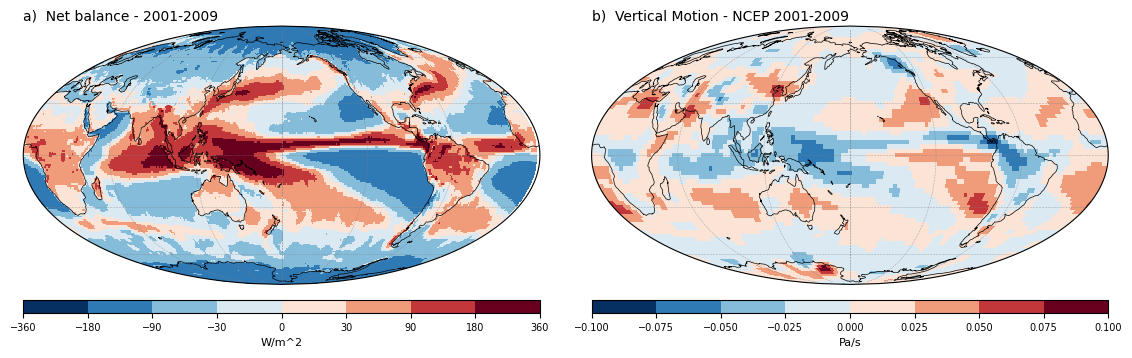

Guardada: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/figuras/fig02_jakob2019.png


In [13]:
# Figura 2 — Jakob et al. (2019)
from matplotlib.colors import BoundaryNorm
from pathlib import Path

# Cargar D_RCE y omega
D_RCE = xr.open_dataarray(OUT_DIR / 'D_RCE_2001_2009.nc')
D_RCE_mean = D_RCE.mean('time').compute()

NCEP_DIR = ROOT / 'datos' / 'ncep' / 'raw'
ds_omega = xr.open_mfdataset(
    sorted(NCEP_DIR.glob('omega*.nc')),
    combine='by_coords'
)
omega_500 = ds_omega['omega'].sel(level=500.0, method='nearest')
omega_mean = omega_500.mean('time').compute()

print(f"D_RCE rango: {float(D_RCE_mean.min()):.1f} → {float(D_RCE_mean.max()):.1f} W/m²")
print(f"omega rango: {float(omega_mean.min()):.4f} → {float(omega_mean.max()):.4f} Pa/s")

# Plot
proj = ccrs.Mollweide(central_longitude=180)
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={'projection': proj})
fig.subplots_adjust(wspace=0.1)

ticks_drce  = [-360, -180, -90, -30, 0, 30, 90, 180, 360]
ticks_omega = [-0.100, -0.075, -0.050, -0.025, 0.000,
                0.025,  0.050,  0.075,  0.100]

configs = [
    (D_RCE_mean,  "a)  Net balance - 2001-2009",
     plt.cm.RdBu_r, ticks_drce,  "W/m^2"),
    (omega_mean,  "b)  Vertical Motion - NCEP 2001-2009",
     plt.cm.RdBu_r, ticks_omega, "Pa/s"),
]

for ax, (da, title, cmap, ticks, unit) in zip(axes, configs):
    norm = BoundaryNorm(ticks, ncolors=256)
    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        transform=ccrs.PlateCarree(),
        cmap=cmap, norm=norm,
        shading='auto'
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
    ax.set_global()
    ax.set_title(title, fontsize=10, pad=4, loc='left')

    # Gridlines punteadas como en el paper
    gl = ax.gridlines(linewidth=0.4, color='gray',
                      alpha=0.6, linestyle='--')

    cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                      pad=0.04, fraction=0.046, shrink=1.0,
                      aspect=40, ticks=ticks)
    cb.set_label(unit, fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.savefig(FIG_DIR / 'fig02_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: {FIG_DIR / 'fig02_jakob2019.png'}")